In [135]:
import numpy as np 
import matplotlib.pyplot as plt



In [136]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2.2, 2.8, 3.6, 4.5, 5.1], dtype=float)

degree = 3  # quadratic polynomial
m = len(x)


In [137]:
x

array([1., 2., 3., 4., 5.])

In [138]:
# 2. Create Polynomial Features
# ---------------------------------
# For degree = 2 → columns: [x, x^2]
X_poly = np.column_stack((x, x**2,x**3))   # shape (5,2)


In [139]:
# 3. Compute feature mean & std correctly
# ---------------------------------
mu = np.mean(X_poly, axis=0)          # shape (2,)
sigma = np.std(X_poly, axis=0)        # shape (2,)
X_scaled = (X_poly - mu) / sigma


In [140]:
X_scaled

array([[-1.41421356, -1.15624323, -0.96522798],
       [-0.70710678, -0.80937026, -0.81166899],
       [ 0.        , -0.23124865, -0.39486599],
       [ 0.70710678,  0.57812161,  0.41680299],
       [ 1.41421356,  1.61874052,  1.75495997]])

In [141]:
# ---------------------------------
# 4. Add bias column
# ---------------------------------
X = np.c_[np.ones((m, 1)), X_scaled]  # shape (5,3)
y = y.reshape(m, 1)


In [142]:
X

array([[ 1.        , -1.41421356, -1.15624323, -0.96522798],
       [ 1.        , -0.70710678, -0.80937026, -0.81166899],
       [ 1.        ,  0.        , -0.23124865, -0.39486599],
       [ 1.        ,  0.70710678,  0.57812161,  0.41680299],
       [ 1.        ,  1.41421356,  1.61874052,  1.75495997]])

In [143]:
# ---------------------------------
# 5. Initialize theta
# ---------------------------------
theta = np.zeros((degree + 1, 1))

In [144]:
theta

array([[0.],
       [0.],
       [0.],
       [0.]])

In [145]:
# 6. Gradient descent setup
# ---------------------------------
alpha = 0.1
iterations = 2000
J_history = []

# ---------------------------------
# 7. Gradient Descent Loop
# ---------------------------------
for i in range(iterations):
    h = X.dot(theta)
    error = h - y
    grad = (1/m) * X.T.dot(error)
    theta = theta - alpha * grad
    J = (1/(2*m)) * np.sum(np.square(error))
    J_history.append(J)

# ---------------------------------
# 8. Display learned parameters
# ---------------------------------
print("Final theta values (bias first):")
print(theta.flatten())


Final theta values (bias first):
[ 3.64        0.83778987  0.48373499 -0.2665061 ]


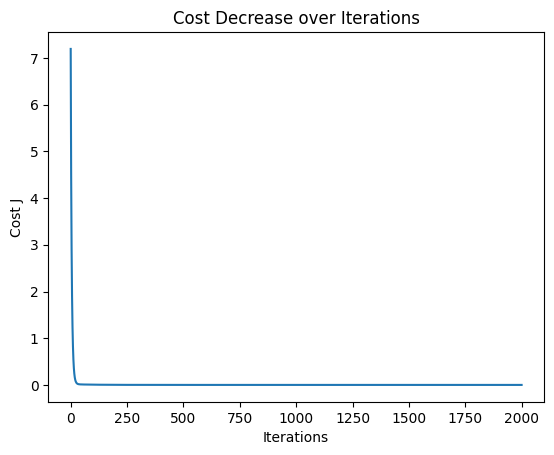

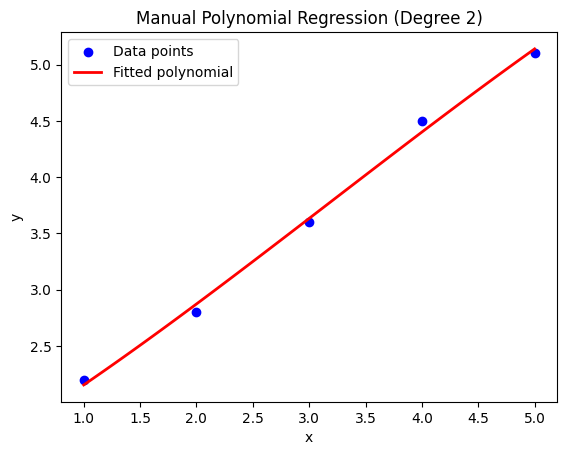

In [146]:
# ---------------------------------
# 9. Plot cost over iterations
# ---------------------------------
plt.plot(J_history)
plt.xlabel("Iterations")
plt.ylabel("Cost J")
plt.title("Cost Decrease over Iterations")
plt.show()

# ---------------------------------
# 10. Plot regression curve
# ---------------------------------
x_plot = np.linspace(1, 5, 100)
x_plot_poly = np.column_stack((x_plot, x_plot**2,x_plot**3))  # shape (100,2)
x_plot_scaled = (x_plot_poly - mu) / sigma  # ✅ same mu & sigma (shape 2,)
X_plot = np.c_[np.ones((len(x_plot), 1)), x_plot_scaled]
y_pred = X_plot.dot(theta)

plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x_plot, y_pred, color='red', linewidth=2, label='Fitted polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Manual Polynomial Regression (Degree 2)')
plt.show()

In [147]:
# ---------------------------------
# 11. Predict for new unseen data
# ---------------------------------
new_x = np.array([6, 7,11], dtype=float)
# Build same polynomial features
new_poly = np.column_stack((new_x, new_x**2, new_x**3))
# Apply same scaling using training mu, sigma
new_scaled = (new_poly - mu) / sigma
# Add bias column
X_new = np.c_[np.ones((len(new_x),1)), new_scaled]
# Predict
predictions = X_new.dot(theta)
print("Predictions for new inputs [6,7]:", predictions.flatten())


Predictions for new inputs [6,7]: [5.81578409 6.39281516 7.01332482]


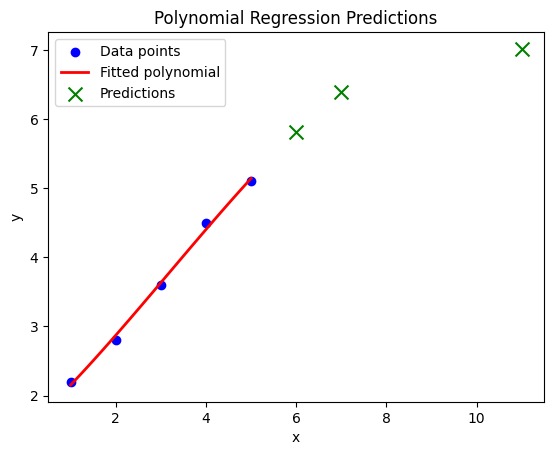

In [148]:
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x_plot, y_pred, color='red', linewidth=2, label='Fitted polynomial')
plt.scatter(new_x, predictions, color='green', marker='x', s=100, label='Predictions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Polynomial Regression Predictions')
plt.show()

built_function used to polynomial regression

Learned parameters (bias first):
[2.14] [[ 0.         -0.27619048  0.38214286 -0.04166667]]


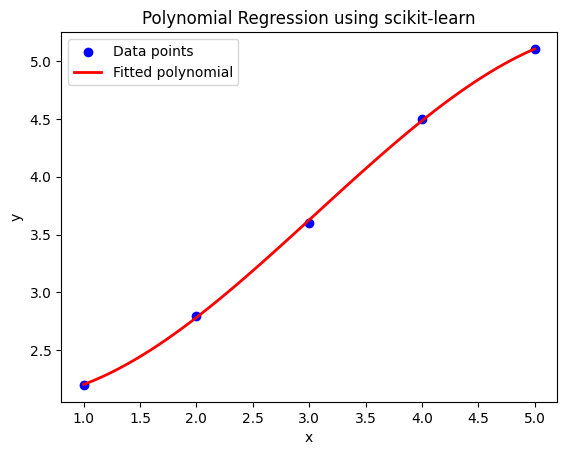

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# Sample data
x = np.array([1, 2, 3, 4, 5], dtype=float).reshape(-1, 1)
y = np.array([2.2, 2.8, 3.6, 4.5, 5.1], dtype=float).reshape(-1, 1)
# Create polynomial features
poly_features = PolynomialFeatures(degree=3)
X_poly = poly_features.fit_transform(x)
# Fit linear regression on polynomial features
model = LinearRegression()
model.fit(X_poly, y)
# Display learned parameters
print("Learned parameters (bias first):")
print(model.intercept_, model.coef_)
# Predict and plot
x_plot = np.linspace(1, 5, 100).reshape(-1, 1)
x_plot_poly = poly_features.transform(x_plot)
y_plot = model.predict(x_plot_poly)
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x_plot, y_plot, color='red', linewidth=2, label='Fitted polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Polynomial Regression using scikit-learn')
plt.show()

